In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
filename = "results_2sat/test_run3_n4.csv"
n = 4 # see csv name (n)

df_results = pd.read_csv(filename)
summary_df = df_results.groupby(['p', 'm'])[['energy_Hc', 'success_prob', 'time_sec']].agg(['mean', 'std']).reset_index()
summary_df.columns = ['_'.join(col).strip('_') for col in summary_df.columns.values]
std_cols = ['energy_Hc_std', 'success_prob_std', 'time_sec_std']
N_iterations = df_results['trial'].nunique()
summary_df[std_cols] = summary_df[std_cols] / np.sqrt(N_iterations) # std mean

# print a summary
print("Summary of the dataset:")
print(f"n qubits/variables: {n}")
print(f"p values: {summary_df['p'].unique()}")
print(f"m values: {summary_df['m'].unique()}")
print(f"Number of trials per (p, m) pair: {N_iterations}")
print("\nSummary DataFrame:")
print(summary_df.head())

Summary of the dataset:
n qubits/variables: 4
p values: [ 1  2  4  8 16]
m values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Number of trials per (p, m) pair: 10

Summary DataFrame:
   p  m  energy_Hc_mean  energy_Hc_std  success_prob_mean  success_prob_std  \
0  1  1    1.287028e-08   4.782567e-09           1.000000          0.000000   
1  1  2    5.808778e-02   3.934369e-02           0.946777          0.037771   
2  1  3    1.960385e-01   5.145287e-02           0.822656          0.053394   
3  1  4    2.739941e-01   6.747381e-02           0.763867          0.050408   
4  1  5    6.257142e-01   8.922899e-02           0.464844          0.079559   

   time_sec_mean  time_sec_std  
0       1.055034      0.044604  
1       1.334179      0.201764  
2       1.338762      0.151646  
3       1.224267      0.142305  
4       1.219863      0.118054  


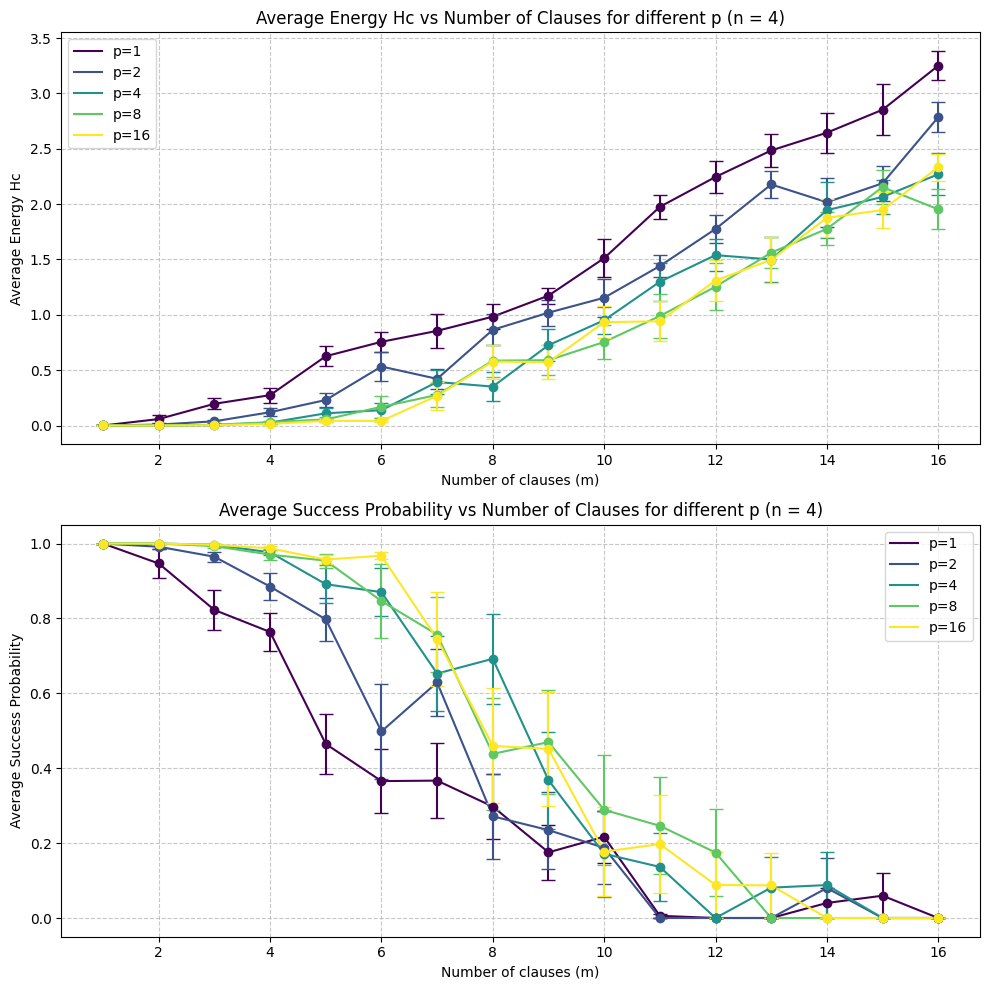

In [26]:
# Plotting the results from summary_df
# Hc energy and success probability vs m for different p values

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
p_list = summary_df['p'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(p_list)))

for idx, p in enumerate(p_list):
    subset = summary_df[summary_df['p'] == p]
    ax[0].plot(subset['m'], subset['energy_Hc_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[0].errorbar(subset['m'], subset['energy_Hc_mean'], yerr=subset['energy_Hc_std'], fmt='o', capsize=5, color=colors[idx])
    ax[1].plot(subset['m'], subset['success_prob_mean'], marker='', label=f'p={p}', color=colors[idx])
    ax[1].errorbar(subset['m'], subset['success_prob_mean'], yerr=subset['success_prob_std'], fmt='o', capsize=5, color=colors[idx])

# plot 1 (Energy)
ax[0].set_xlabel('Number of clauses (m)')
ax[0].set_ylabel('Average Energy Hc')
ax[0].set_title(f'Average Energy Hc vs Number of Clauses for different p (n = {n})')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# plot 2 (Success Probability)
ax[1].set_xlabel('Number of clauses (m)')
ax[1].set_ylabel('Average Success Probability')
ax[1].set_title(f'Average Success Probability vs Number of Clauses for different p (n = {n})')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()